In [1]:
import sys, re, json
sys.path.append('..') 

from scripts.constants import *
from scripts.utils import *
from scripts.sedona_config import *

import pandas as pd
import geopandas as gpd

In [2]:
T3_30_300_DIR = VECTOR_OUT_DIR / "3-30-300"
T3_dir = T3_30_300_DIR / "T3"
T30_dir = T3_30_300_DIR / "T30"
T300_dir = T3_30_300_DIR / "T300"
t3_30_300_path = T3_30_300_DIR / "T3_30_300.geojson"
imd_lsoa_bua_boundaries_path = VECTOR_OUT_DIR / "IMD" / "English_IMD_2019_BUA_filtered_boundaries.geojson"
imd_england_path = VECTOR_IN_DIR / "IMD" / "English IMD 2019" / "IMD_2019.shp"
buildings_path = VECTOR_IN_DIR / "EDINA" / "Buildings_6183" / "Buildings_6183.parquet"

In [3]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'
imd_lsoa_bua_gdf = gpd.read_file(imd_lsoa_bua_boundaries_path)
geo_level_codes = imd_lsoa_bua_gdf[geo_level].unique()
imd_england_columns = ['lsoa11cd', 'TotPop', 'DepChi', 'Pop16_59', 'Pop60+', 'WorkPop',
                       'IMD_Rank', 'IMD_Decile', 'IMDScore', 'IncScore', 'IncRank', 'IncDec', 
                       'EmpScore', 'EmpRank', 'EmpDec', 'EduScore', 'EduRank', 'EduDec', 
                       'HDDScore', 'HDDRank', 'HDDDec', 'CriScore', 'CriRank', 'CriDec', 
                       'BHSScore', 'BHSRank', 'BHSDec', 'EnvScore', 'EnvRank', 'EnvDec']
imd_england_gdf = gpd.read_file(imd_england_path)[imd_england_columns]

In [4]:
os.environ["JAVA_HOME"] = JAVA_HOME
sedona = get_spark()

24/12/13 15:16:56 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
24/12/13 15:16:56 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-224a686b-4868-4e8a-a838-2521ebb2f35b;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in central
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.error

In [5]:
boundaries_sdf = sedona.createDataFrame(imd_lsoa_bua_gdf.drop(columns=['LSOA21NMW', 'LAD22NMW', 'BUA22NMG', 'BUA22NMW', 'RGN22NMW'], axis=1))
boundaries_sdf.createOrReplaceTempView('boundaries')
imd_england_sdf = sedona.createDataFrame(imd_england_gdf)
imd_england_sdf.createOrReplaceTempView('imd_england')
buildings_sdf = sedona.read.format("geoparquet").load(str(buildings_path))
buildings_sdf.createOrReplaceTempView("buildings")

In [6]:
t3_sdf = sedona.read.csv(str(T3_dir), header=True, inferSchema=True)
t3_sdf.createOrReplaceTempView("t3")
t30_sdf = sedona.read.csv(str(T30_dir), header=True, inferSchema=True)
t30_sdf.createOrReplaceTempView("t30")
t300_sdf = sedona.read.csv(str(T300_dir), header=True, inferSchema=True)
t300_sdf.createOrReplaceTempView("t300")

In [7]:
# Perform spatial join
buildings_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, l.LSOA11CD
    FROM buildings b
    JOIN boundaries l
    ON ST_Contains(l.geometry, b.geometry)
    """
)
buildings_lsoa_sdf.createOrReplaceTempView("buildings")

In [8]:
buildings_sdf.groupBy("map_use").count().orderBy("count", ascending=False).show()

24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized reader. Falling back to parquet-mr
24/12/13 15:17:46 WARN GeoParquetFileFormat: GeoParquet currently does not support vectorized rea

+--------------------+--------+
|             map_use|   count|
+--------------------+--------+
|         Residential|24697879|
|             Unknown| 1141942|
|        Agricultural|  828528|
|Commercial - mixe...|  798021|
|Recreation and le...|  297022|
|Retail below offi...|  247084|
|            Industry|  184183|
|              Retail|  175795|
|         Educational|  167665|
|              Office|   72740|
|           Religious|   67110|
|Institutional acc...|   43958|
|           Utilities|   37985|
|           Transport|   35858|
|              Health|   35365|
|        Unclassified|   24669|
|         Complex use|   15604|
|        Governmental|   14061|
|Residential with ...|   11000|
|Commercial - dere...|   10424|
+--------------------+--------+
only showing top 20 rows



In [16]:
t30_imd_lsoa_sdf = sedona.sql(
    """
    SELECT b.*, ROUND(ST_Area(b.geometry), 2) AS area, i.*, t.canopy_cover
    FROM boundaries b
    LEFT JOIN imd_england i ON b.LSOA11CD = i.lsoa11cd
    LEFT JOIN t30 t ON b.LSOA11CD = t.LSOA11CD
    """
)
t30_imd_lsoa_sdf.createOrReplaceTempView("t30_imd_lsoa")
t30_imd_lsoa_sdf.show()

+---------+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------+-------+--------------------+---------+---------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+
| LSOA11CD|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|             LAD22NM|  BUA22CD|             BUA22NM|  RGN22CD|RGN22NM|            geometry|     area| lsoa11cd|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|
+---------+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------

In [10]:
t3_300_building_sdf = sedona.sql(
    """
    SELECT b.*, t3.tree_count, t300.closest_park_access_id, t300.distance
    FROM buildings b
    LEFT JOIN t3 ON b.verisk_premise_id = t3.verisk_premise_id
    LEFT JOIN t300 ON b.verisk_premise_id = t300.verisk_premise_id
    """
)
t3_300_building_sdf.createOrReplaceTempView("t3_300_building")
t3_300_building_sdf.show()

24/12/13 15:18:17 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+-------------+-----------------+--------------+------+---------------+--------------------+-------------------+--------------------+--------------------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|building_area|distance_building|distance_water|height| map_simple_use|             map_use|premise_floor_count|        premise_type|         premise_use|premise_year|verisk_building_id|verisk_premise_id|            geometry| LSOA11CD|tree_count|closest_park_access_id|distance|
+-------------+-----------------+--------------+------+---------------+--------------------+-------------------+--------------------+--------------------+------------+------------------+-----------------+--------------------+---------+----------+----------------------+--------+
|        110.2|              0.0|         447.4|   8.1|    Residential|         Residential|                  2|       Semi-detached|         Residential|        N

In [11]:
t3_300_lsoa_sdf = sedona.sql(
    """
    SELECT LSOA11CD, ROUND(AVG(tree_count), 2) as tree_count, ROUND(AVG(distance), 2) as park_distance
    FROM t3_300_building
    GROUP BY LSOA11CD
    """
)

t3_300_lsoa_sdf.createOrReplaceTempView("t3_300_lsoa")
t3_300_lsoa_sdf.show()

24/12/13 15:19:08 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+---------+----------+-------------+
| LSOA11CD|tree_count|park_distance|
+---------+----------+-------------+
|E01029873|      NULL|      2141.94|
|E01026615|      NULL|      1981.59|
|E01026048|      NULL|     Infinity|
|E01022207|      NULL|      6844.61|
|E01023494|      NULL|      3440.36|
|E01031876|      NULL|      3456.38|
|E01027281|      NULL|       655.67|
|E01027633|      NULL|      6460.16|
|E01027571|      NULL|      4335.07|
|E01012927|      NULL|      1130.55|
|E01031630|      NULL|       399.14|
|E01019498|      NULL|       337.37|
|E01017869|      NULL|      1743.83|
|E01012567|      NULL|        472.8|
|E01031518|      NULL|     Infinity|
|E01020314|      NULL|     Infinity|
|E01028794|      NULL|      3429.28|
|E01019607|      NULL|      3936.35|
|E01024347|      NULL|      2844.73|
|E01013256|      NULL|       447.94|
+---------+----------+-------------+
only showing top 20 rows



In [17]:
t3_30_300_sdf = t30_imd_lsoa_sdf.join(t3_300_lsoa_sdf, on="LSOA11CD", how="inner")
t3_30_300_sdf = t3_30_300_sdf.drop("lsoa11cd")
t3_30_300_sdf.createOrReplaceTempView("t3_30_300")
t3_30_300_sdf.show()

24/12/13 15:34:57 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


+--------------------+---------+--------------------+---------+--------------------+---------+--------------------+---------+---------------+--------------------+---------+------+------+--------+------+-------+--------+----------+--------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+--------+-------+------+------------+----------+-------------+
|            LSOA11NM| LSOA21CD|            LSOA21NM|  LAD22CD|             LAD22NM|  BUA22CD|             BUA22NM|  RGN22CD|        RGN22NM|            geometry|     area|TotPop|DepChi|Pop16_59|Pop60+|WorkPop|IMD_Rank|IMD_Decile|IMDScore|IncScore|IncRank|IncDec|EmpScore|EmpRank|EmpDec|EduScore|EduRank|EduDec|HDDScore|HDDRank|HDDDec|CriScore|CriRank|CriDec|BHSScore|BHSRank|BHSDec|EnvScore|EnvRank|EnvDec|canopy_cover|tree_count|park_distance|
+--------------------+---------+--------------------+---------+--------------------+---------+--------------

In [18]:
# t3_30_300_df = t3_30_300_sdf.toPandas()
# t3_30_300_df = t3_30_300_df.replace([float('inf'), float('-inf')], pd.NA)
t3_30_300_sdf.write.mode("overwrite").format("geojson").save(str(t3_30_300_path))

24/12/13 15:42:05 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.


In [18]:
t3_30_300_df = gpd.read_file(t3_30_300_path)

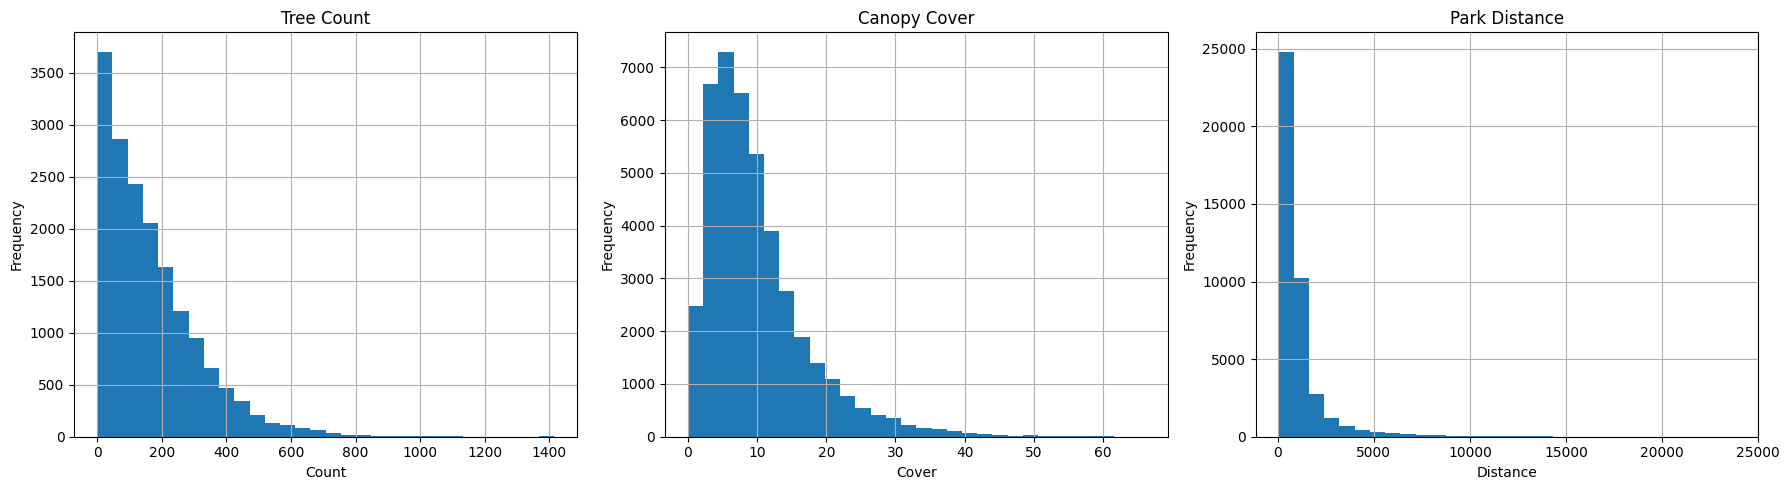

In [30]:
import matplotlib.pyplot as plt

# Create histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t3_30_300_df['tree_count'].hist(ax=axes[0], bins=30)
axes[0].set_title('Tree Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')

t3_30_300_df['canopy_cover'].hist(ax=axes[1], bins=30)
axes[1].set_title('Canopy Cover')
axes[1].set_xlabel('Cover')
axes[1].set_ylabel('Frequency')

t3_30_300_df['park_distance'].hist(ax=axes[2], bins=30)
axes[2].set_title('Park Distance')
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()